In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine


In [2]:
democracy=pd.read_csv("global_democracy_index.csv")
democracy=pd.DataFrame(data=democracy)  

In [3]:
democracy

,country_code,country_name,score_2018,score_2022
0,AFG,Afghanistan,2.97,0.32
1,AGO,Angola,3.62,3.96
2,ALB,Albania,5.98,6.41
3,ARE,United Arab Emirates,2.76,2.90
4,ARG,Argentina,7.02,6.85
...,...,...,...,...
162,VNM,Viet Nam,3.08,2.73
163,YEM,"Yemen, Rep.",1.95,1.95
164,ZAF,South Africa,7.24,7.05
165,ZMB,Zambia,5.61,5.80


In [4]:
f=democracy.sort_values(by='score_2018',ascending=False)

In [5]:
f.head()

,country_code,country_name,score_2018,score_2022
114,NOR,Norway,9.87,9.81
73,ISL,Iceland,9.58,9.52
142,SWE,Sweden,9.39,9.39
116,NZL,New Zealand,9.26,9.61
40,DNK,Denmark,9.22,9.28


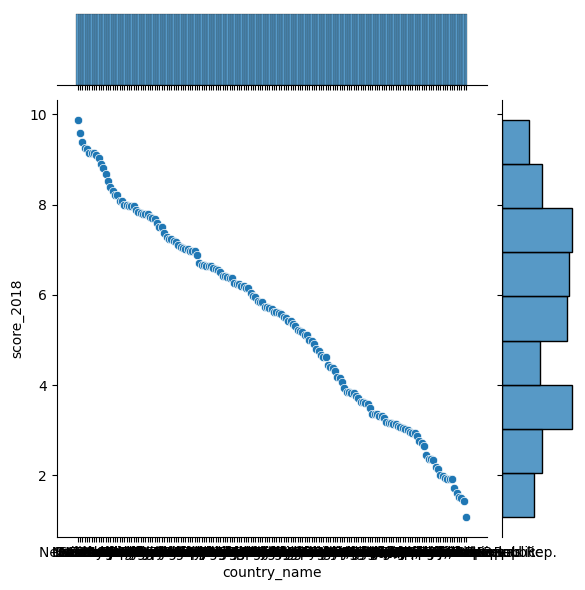

In [6]:
sns.jointplot(data=f,x='country_name',y='score_2018')

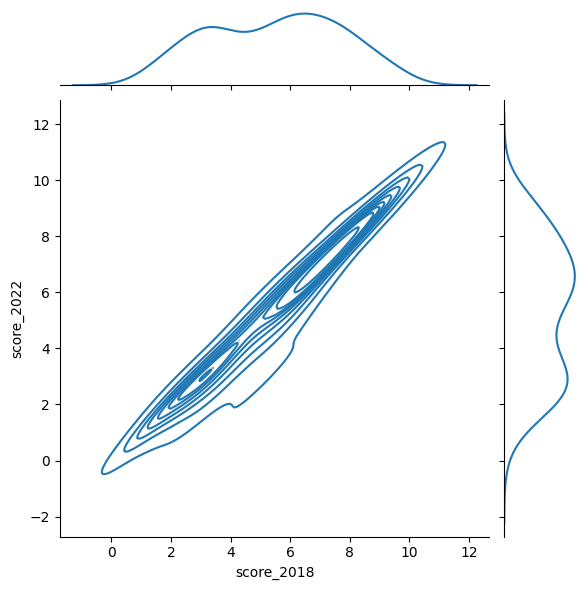

In [7]:
# Plot KDE of two democracy scores (different years)
sns.jointplot(data=f, x='score_2018', y='score_2022', kind='kde')

In [16]:
democracy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country_code  167 non-null    object 
 1   country_name  167 non-null    object 
 2   score_2018    167 non-null    float64
 3   score_2022    167 non-null    float64
dtypes: float64(2), object(2)
memory usage: 5.3+ KB


In [17]:
democracy.describe()

,score_2018,score_2022
count,167.000000,167.000000
mean,5.478563,5.293174
std,2.199400,2.375860
min,1.080000,0.320000
25%,3.545000,3.110000
50%,5.690000,5.540000
75%,7.175000,7.100000
max,9.870000,9.810000


In [18]:
democracy.describe(include='all')

,country_code,country_name,score_2018,score_2022
count,167,167,167.000000,167.000000
unique,167,167,NaN,NaN
top,AFG,Afghanistan,NaN,NaN
freq,1,1,NaN,NaN
mean,NaN,NaN,5.478563,5.293174
std,NaN,NaN,2.199400,2.375860
min,NaN,NaN,1.080000,0.320000
25%,NaN,NaN,3.545000,3.110000
50%,NaN,NaN,5.690000,5.540000
75%,NaN,NaN,7.175000,7.100000


In [21]:
democracy.isna().any()

country_code    False
country_name    False
score_2018      False
score_2022      False
dtype: bool

In [20]:
democracy.isna().count()

country_code    167
country_name    167
score_2018      167
score_2022      167
dtype: int64

In [22]:
democracy[democracy['score_2018']<5]

,country_code,country_name,score_2018,score_2022
0,AFG,Afghanistan,2.97,0.32
1,AGO,Angola,3.62,3.96
3,ARE,United Arab Emirates,2.76,2.90
5,ARM,Armenia,4.79,5.63
8,AZE,Azerbaijan,2.65,2.87
...,...,...,...,...
160,UZB,Uzbekistan,2.01,2.12
161,VEN,"Venezuela, RB",3.16,2.23
162,VNM,Viet Nam,3.08,2.73
163,YEM,"Yemen, Rep.",1.95,1.95


In [30]:
democracy[(democracy['score_2018']>2)]

,country_code,country_name,score_2018,score_2022
0,AFG,Afghanistan,2.97,0.32
1,AGO,Angola,3.62,3.96
2,ALB,Albania,5.98,6.41
3,ARE,United Arab Emirates,2.76,2.90
4,ARG,Argentina,7.02,6.85
...,...,...,...,...
161,VEN,"Venezuela, RB",3.16,2.23
162,VNM,Viet Nam,3.08,2.73
164,ZAF,South Africa,7.24,7.05
165,ZMB,Zambia,5.61,5.80


In [33]:
democracy[(democracy['score_2018']>7) & (democracy['score_2022']<10)]

,country_code,country_name,score_2018,score_2022
4,ARG,Argentina,7.02,6.85
6,AUS,Australia,9.09,8.71
7,AUT,Austria,8.29,8.20
10,BEL,Belgium,7.78,7.64
14,BGR,Bulgaria,7.03,6.53
21,BWA,Botswana,7.81,7.73
23,CAN,Canada,9.15,8.88
24,CHE,Switzerland,9.03,9.14
25,CHL,Chile,7.97,8.22
33,CPV,Cabo Verde,7.88,7.65


In [ ]:
democracy[(democracy['score_2018']>7) & (democracy['score_2022']<10)].count()

country_code    167
country_name    167
score_2018      167
score_2022      167
dtype: int64

In [42]:
democracy['rank1']=democracy['score_2018'].rank(ascending=False)
democracy['rank2']=democracy['score_2022'].rank(ascending=False)

In [43]:
democracy.groupby('rank')['country_name'].apply('max')

rank
1.0      Korea, Dem. People's Rep.
2.0           Syrian Arab Republic
3.0               Congo, Dem. Rep.
4.0       Central African Republic
5.0                           Chad
                   ...            
163.0                      Denmark
164.0                  New Zealand
165.0                       Sweden
166.0                      Iceland
167.0                       Norway
Name: country_name, Length: 146, dtype: object

In [44]:
democracy

,country_code,country_name,score_2018,score_2022,rank,rank1,rank2
0,AFG,Afghanistan,2.97,0.32,25.0,143.0,167.0
1,AGO,Angola,3.62,3.96,45.0,123.0,109.0
2,ALB,Albania,5.98,6.41,92.0,76.0,64.0
3,ARE,United Arab Emirates,2.76,2.90,21.0,147.0,133.0
4,ARG,Argentina,7.02,6.85,120.5,47.5,50.0
...,...,...,...,...,...,...,...
162,VNM,Viet Nam,3.08,2.73,29.0,139.0,138.0
163,YEM,"Yemen, Rep.",1.95,1.95,10.0,158.0,155.0
164,ZAF,South Africa,7.24,7.05,128.0,40.0,45.0
165,ZMB,Zambia,5.61,5.80,82.0,86.0,78.0


<Axes: ylabel='score_2018'>

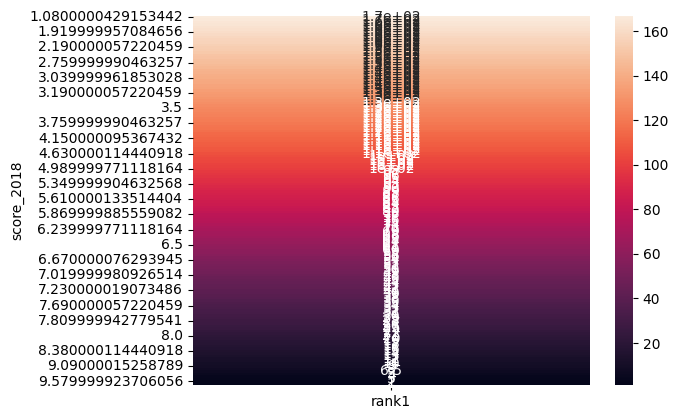

In [57]:
f=pd.pivot_table(democracy,index='score_2018',values='rank1')
sns.heatmap(f,annot=True,)

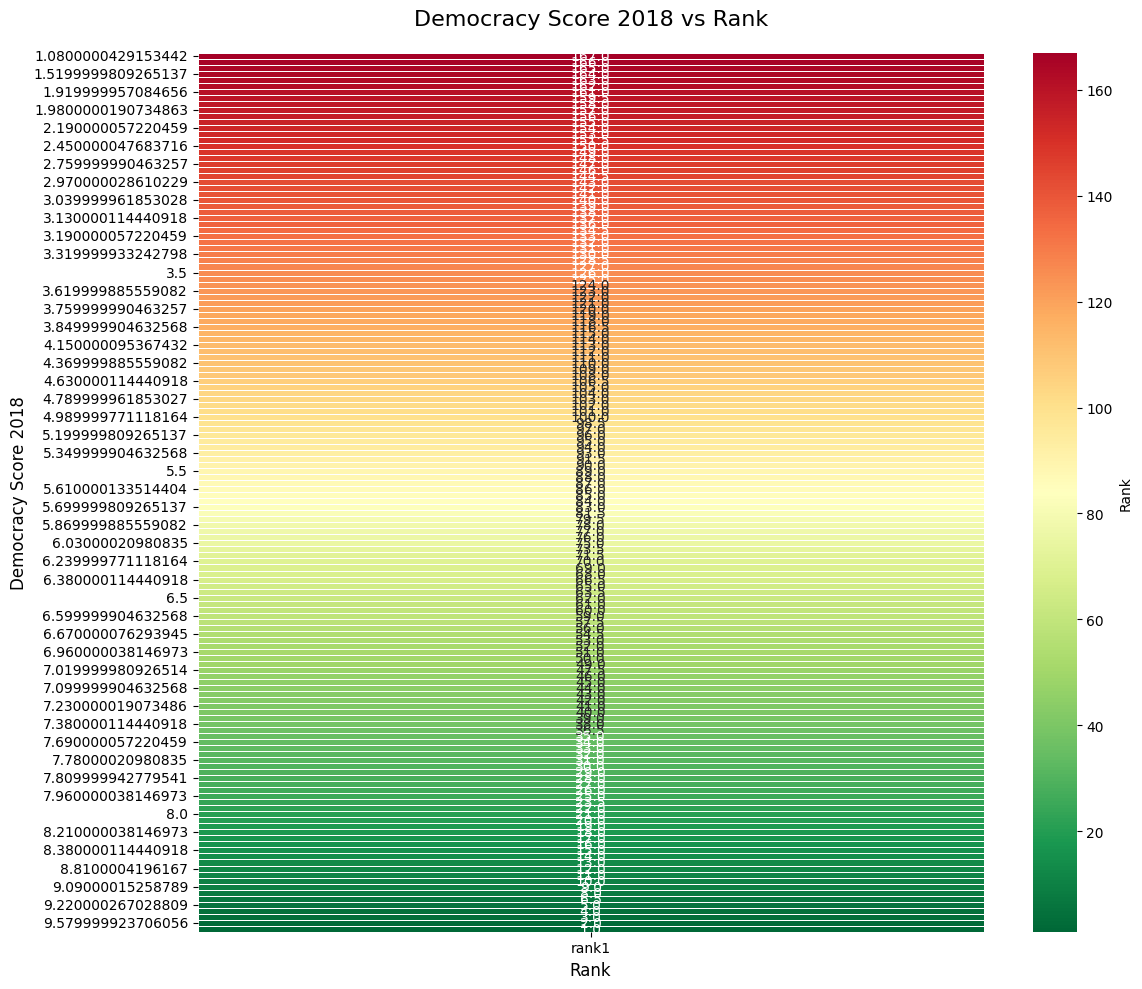

In [58]:
f = pd.pivot_table(democracy, index='score_2018', values='rank1')

plt.figure(figsize=(12, 10))
sns.heatmap(f, annot=True, fmt='.1f', cmap='RdYlGn_r', 
            linewidths=0.5, cbar_kws={'label': 'Rank'})
plt.title('Democracy Score 2018 vs Rank', fontsize=16, pad=20)
plt.xlabel('Rank', fontsize=12)
plt.ylabel('Democracy Score 2018', fontsize=12)
plt.tight_layout()

In [52]:
f

,score_2018
rank1,
1.0,9.87
2.0,9.58
3.0,9.39
4.0,9.26
5.0,9.22
...,...
163.0,1.61
164.0,1.52
165.0,1.49
